<a href="https://colab.research.google.com/github/nyosef1108/multilayer-perceptron-from-scratch/blob/main/DEMO1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Training...
Epoch    0: Loss = 0.2266, Accuracy = 69.5%
Epoch  100: Loss = 0.0211, Accuracy = 98.0%
Epoch  200: Loss = 0.0110, Accuracy = 99.5%
Epoch  300: Loss = 0.0085, Accuracy = 99.0%
Epoch  400: Loss = 0.0072, Accuracy = 99.5%
Epoch  500: Loss = 0.0061, Accuracy = 99.5%
Epoch  600: Loss = 0.0059, Accuracy = 99.5%
Epoch  700: Loss = 0.0056, Accuracy = 99.0%
Epoch  800: Loss = 0.0050, Accuracy = 99.0%
Epoch  900: Loss = 0.0048, Accuracy = 99.5%
Epoch 1000: Loss = 0.0047, Accuracy = 100.0%


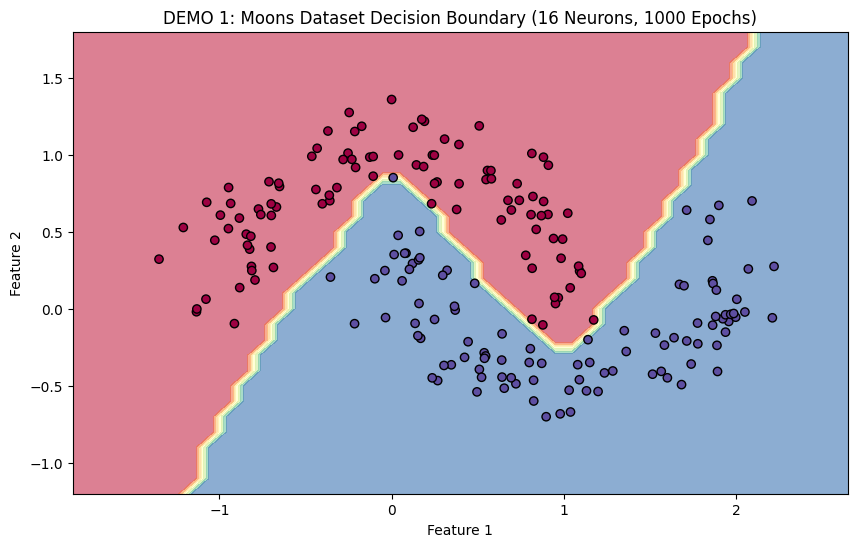

In [1]:
# 1. Install the package from PyPI
!pip install multilayer-perceptron-from-scratch

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from multilayer_perceptron import Network

# 2. Generate the Moons Dataset
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)
# Prepare data: list of (input_vector, target_vector)
training_data = [(xi.reshape(2, 1), np.array([[float(yi)]])) for xi, yi in zip(X, y)]

# 3. Initialize the Network
# Architecture: 2 inputs -> 16 hidden neurons -> 1 output
mlp = Network([2, 16, 1])

# 4. Train the Network using SGD
print("Starting Training...")
# Changed to 1001 epochs for 1000 full iterations
mlp.SGD(training_data, epochs=1001, learning_rate=0.1)

# 5. Visualization of the Decision Boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = []
for p in np.c_[xx.ravel(), yy.ravel()]:
    # Use feedforward to get prediction for each point in the grid
    out, _, _ = mlp.feedforward(p.reshape(2, 1))
    Z.append(1 if out >= 0.5 else 0)

Z = np.array(Z).reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolors='k')
plt.title("DEMO 1: Moons Dataset Decision Boundary (16 Neurons, 1000 Epochs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()